Exploratory data analysis -> miss abstract and sometime authors -> merge by id since id unique

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import sys
from pathlib import Path

# Add project root so notebook can import from src/
PROJECT_ROOT = Path("../").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_PATH_STAGE2, TEST_PATH_STAGE2
from src.utils.utils import load_csv, preview_df

train_df = load_csv(TRAIN_PATH_STAGE2)
test_df = load_csv(TEST_PATH_STAGE2)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train path:", TRAIN_PATH_STAGE2)
print("Test path:", TEST_PATH_STAGE2)

preview_df(train_df)

Train shape: (2494, 7)
Test shape: (596, 6)
Train path: /Users/nhatnam/Documents/DM_252/Assignment/data/raw/Stage2/train.csv
Test path: /Users/nhatnam/Documents/DM_252/Assignment/data/raw/Stage2/public_test.csv
Shape: (2494, 7)
Columns: ['id', 'title', 'venue', 'year', 'authors', 'doi', 'Label']


,id,title,venue,year,authors,doi,Label
0,0,"Proceedings 41st International Conference on Logic Programming, ICLP 2025, Rende, Italy, 12-19th September 2025.",iclp,2026,Paul Tarau,https://www.semanticscholar.org/paper/f7391104e89d3ae6456960c316a2758d5850e6b0,1
1,1,Conditionals and Temporal Conditionals for Gradual Argumentation.,iclp,2025,NaN,https://www.semanticscholar.org/paper/8328d53dae0b05fd09b0d1f2326bda354ee250b7,1
2,2,Learning and Contesting Assumption-based Argumentation Frameworks (Invited Talk).,iclp,2025,"Ofer Arieli, Jesse Heyninck",https://www.semanticscholar.org/paper/1c433ff0c724aeaa6449948f3f99ec30a20e9bc5,2
3,3,Agentified Argumentative Learning (short paper).,iclp,2025,NaN,https://www.semanticscholar.org/paper/666f0fa6242f59f0efad52bf4fca6e57dec3df21,1
4,4,Empowering Public Interest Communication with Argumentation - Project Report (short paper).,iclp,2025,Alejandra Casas Niño de Rivera,https://www.semanticscholar.org/paper/08195948156fdb7d400d37e1cd8af51fbcd2918b,1


In [3]:
print("===== TRAIN MISSING VALUES =====")
display(train_df.isnull().sum().to_frame("Missing Count"))

print("\n===== TEST MISSING VALUES =====")
display(test_df.isnull().sum().to_frame("Missing Count"))

===== TRAIN MISSING VALUES =====


,Missing Count
id,0
title,0
venue,0
year,0
authors,192
doi,0
Label,0



===== TEST MISSING VALUES =====


,Missing Count
id,0
title,0
venue,0
year,0
authors,41
doi,0


===== LABEL DISTRIBUTION =====


,Count
Label,
1,903
2,514
3,438
4,367
5,272


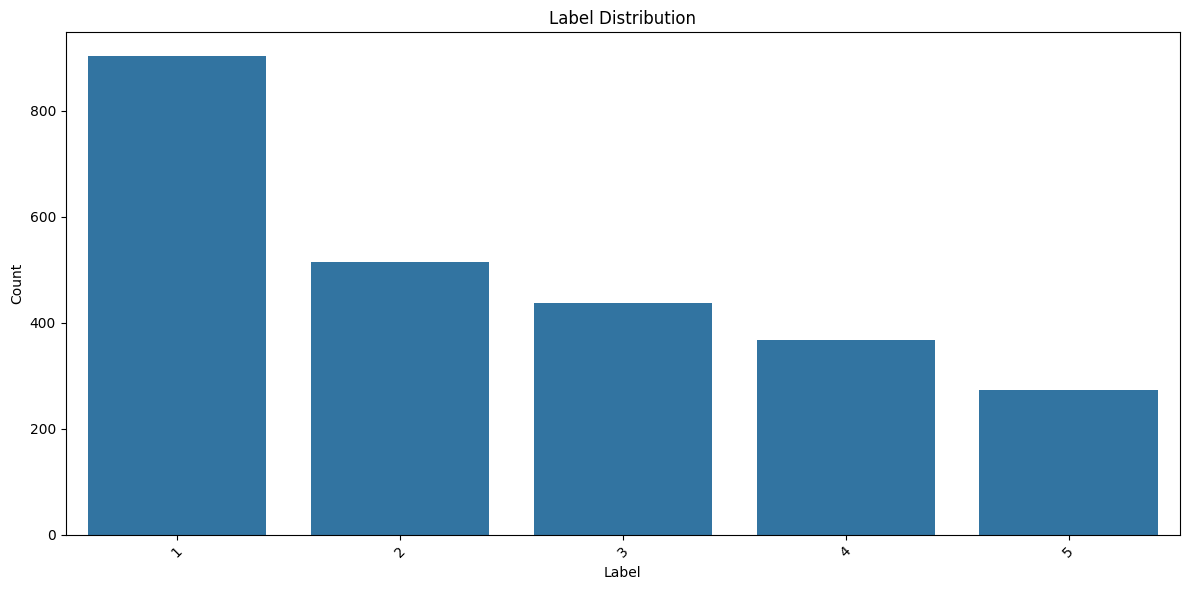

In [4]:
print("===== LABEL DISTRIBUTION =====")

label_counts = train_df["Label"].value_counts().sort_index()

display(label_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.countplot(
    data=train_df,
    x="Label",
    order=sorted(train_df["Label"].unique())
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
print("===== DUPLICATE CHECK : TRAIN =====")

print("Duplicate IDs:", train_df["id"].duplicated().sum())
print("Duplicate Titles:", train_df["title"].duplicated().sum())
print("Duplicate DOI:", train_df["doi"].duplicated().sum())
print("Duplicate Full Rows:", train_df.duplicated().sum())


print("\n===== DUPLICATE CHECK : TEST =====")

print("Duplicate IDs:", test_df["id"].duplicated().sum())
print("Duplicate Titles:", test_df["title"].duplicated().sum())
print("Duplicate DOI:", test_df["doi"].duplicated().sum())
print("Duplicate Full Rows:", test_df.duplicated().sum())

===== DUPLICATE CHECK : TRAIN =====
Duplicate IDs: 0
Duplicate Titles: 9
Duplicate DOI: 38
Duplicate Full Rows: 0

===== DUPLICATE CHECK : TEST =====
Duplicate IDs: 0
Duplicate Titles: 0
Duplicate DOI: 1
Duplicate Full Rows: 0


===== TOP VENUES : TRAIN =====


,Count
venue,
kr,661
cav,657
lics,604
iclp,456
lpnmr,116


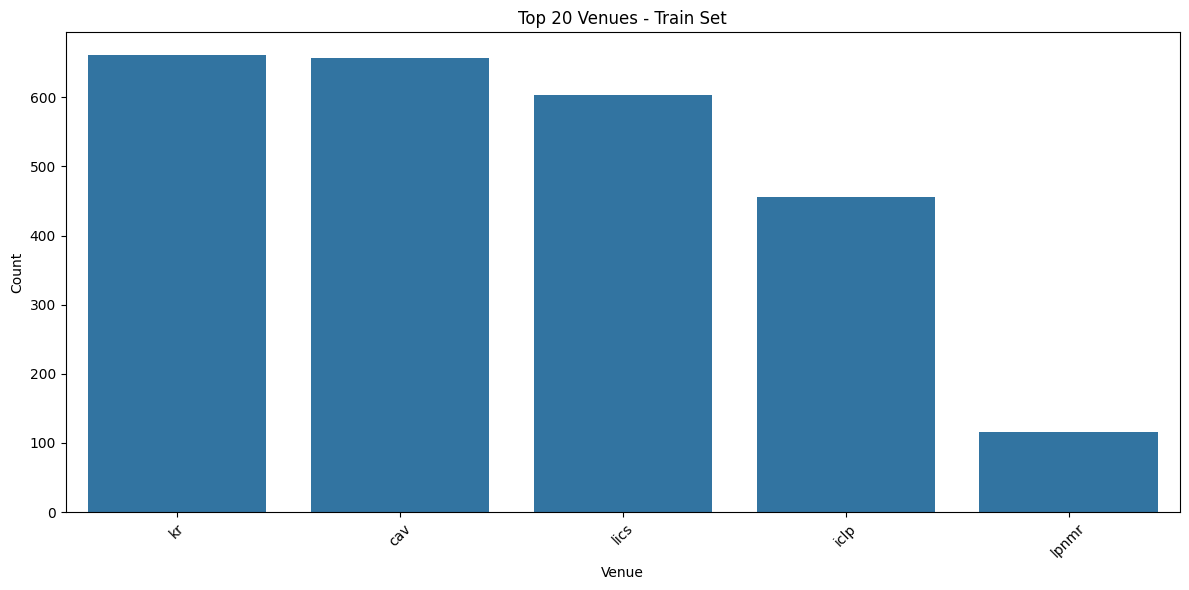

===== TOP VENUES : TEST =====


,Count
venue,
cav,221
lics,187
kr,151
lpnmr,37


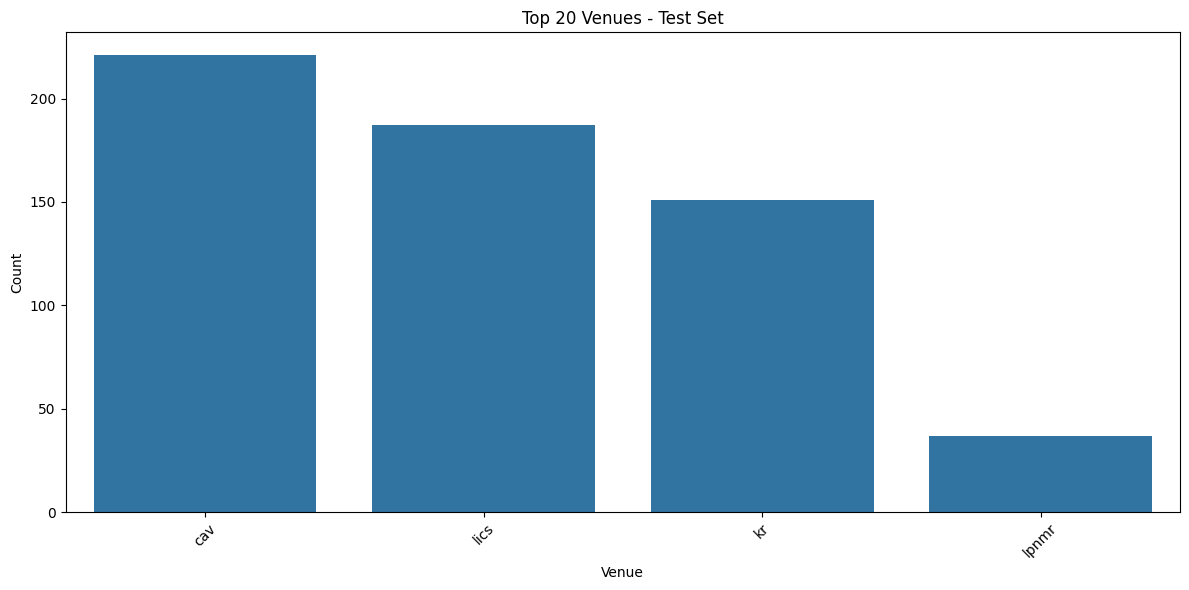

In [6]:
print("===== TOP VENUES : TRAIN =====")

train_venue_counts = train_df["venue"].value_counts().head(20)

display(train_venue_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.barplot(
    x=train_venue_counts.index,
    y=train_venue_counts.values
)

plt.title("Top 20 Venues - Train Set")
plt.xlabel("Venue")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("===== TOP VENUES : TEST =====")

test_venue_counts = test_df["venue"].value_counts().head(20)

display(test_venue_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.barplot(
    x=test_venue_counts.index,
    y=test_venue_counts.values
)

plt.title("Top 20 Venues - Test Set")
plt.xlabel("Venue")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

===== YEAR DISTRIBUTION : TRAIN =====


,Count
year,
2016,223
2017,191
2018,237
2019,230
2020,254
2021,264
2022,224
2023,263
2024,313


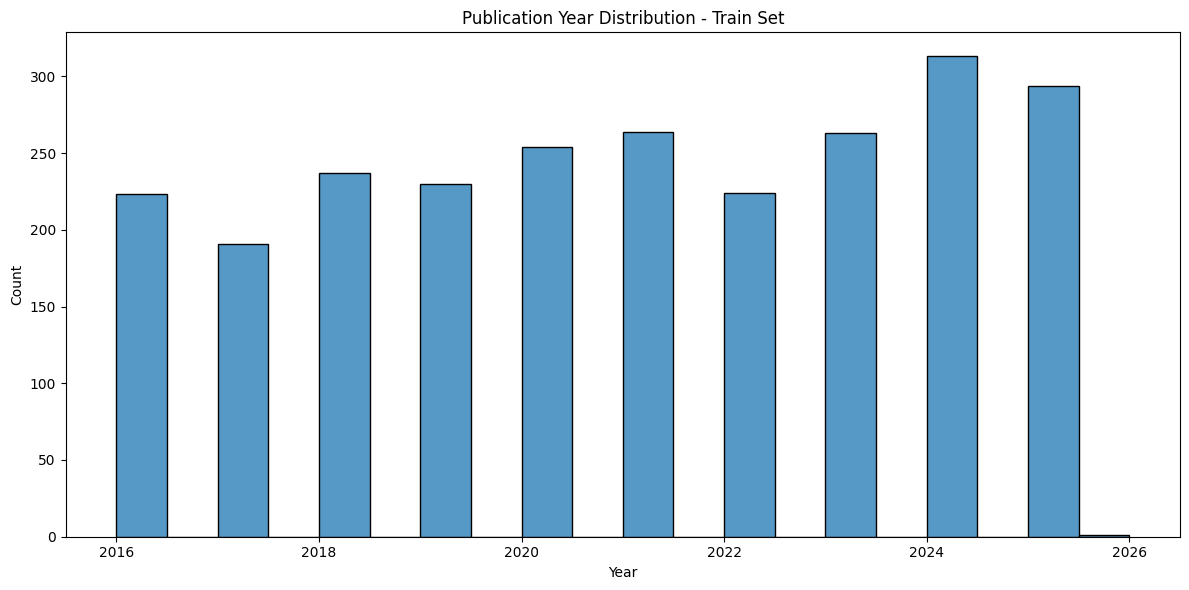

===== YEAR DISTRIBUTION : TEST =====


,Count
year,
2016,56
2017,51
2018,93
2019,58
2020,75
2021,73
2022,61
2023,47
2024,45


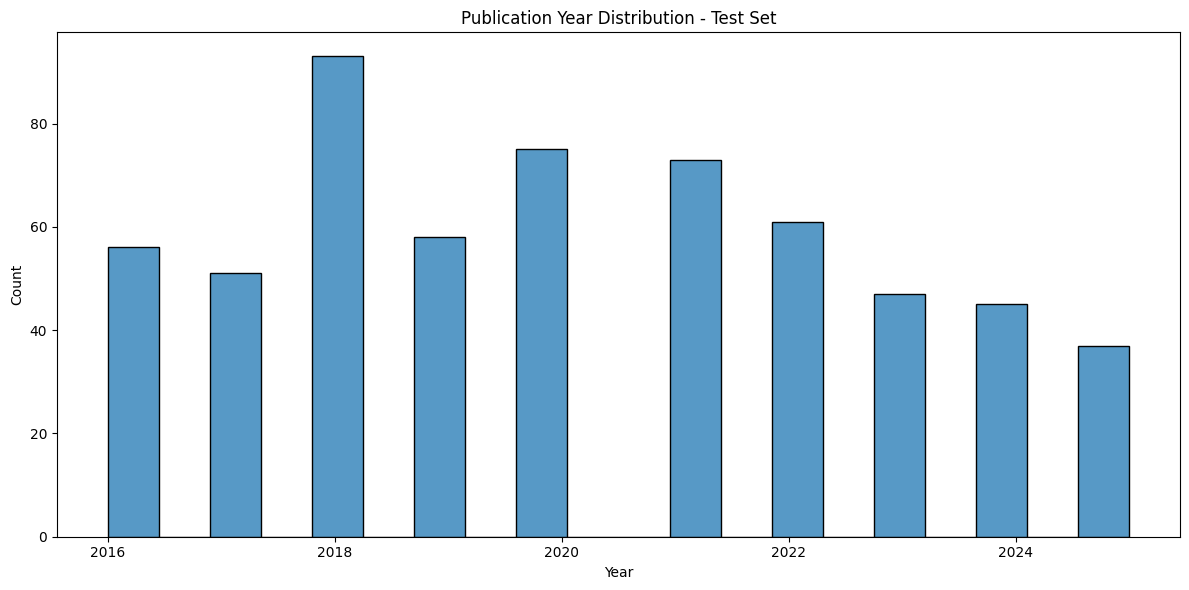

In [7]:
print("===== YEAR DISTRIBUTION : TRAIN =====")

train_year_counts = train_df["year"].value_counts().sort_index()

display(train_year_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.histplot(train_df["year"], bins=20)

plt.title("Publication Year Distribution - Train Set")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


print("===== YEAR DISTRIBUTION : TEST =====")

test_year_counts = test_df["year"].value_counts().sort_index()

display(test_year_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.histplot(test_df["year"], bins=20)

plt.title("Publication Year Distribution - Test Set")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

===== NUMBER OF AUTHORS =====


count    2494.000000
mean        2.801123
std         1.682042
min         1.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        18.000000
Name: num_authors, dtype: float64

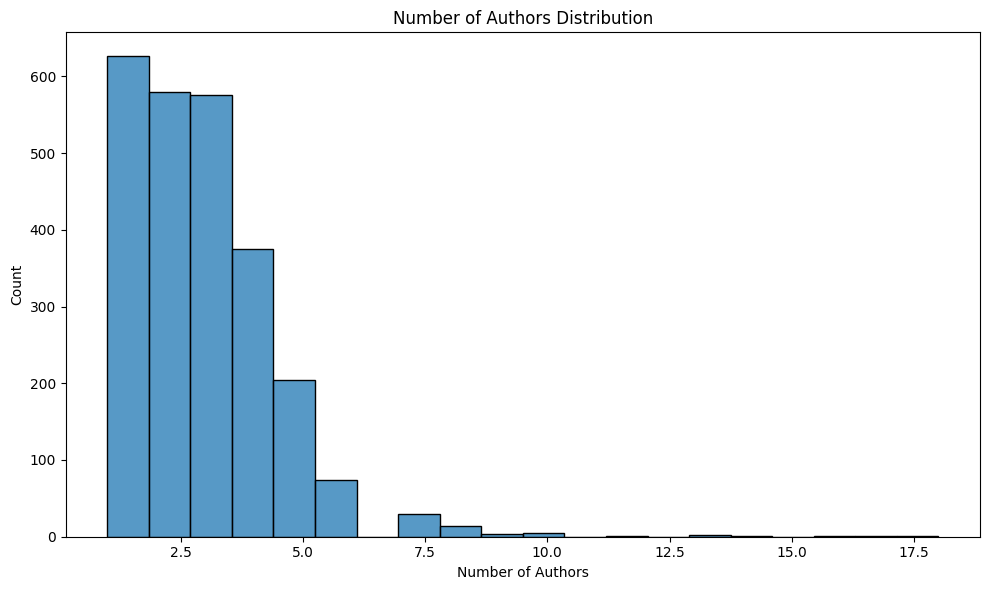

In [8]:
train_df["num_authors"] = train_df["authors"].apply(
    lambda x: len(str(x).split(","))
)

print("===== NUMBER OF AUTHORS =====")

display(train_df["num_authors"].describe())

plt.figure(figsize=(10, 6))
sns.histplot(train_df["num_authors"], bins=20)

plt.title("Number of Authors Distribution")
plt.xlabel("Number of Authors")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [9]:
print("===== DUPLICATE ID CHECK : TRAIN =====")

train_duplicate_id_count = train_df["id"].duplicated().sum()

print(f"Duplicate IDs in train set: {train_duplicate_id_count}")

if train_duplicate_id_count > 0:
    display(
        train_df[
            train_df["id"].duplicated(keep=False)
        ].sort_values("id")
    )
else:
    print("No duplicate IDs found in train set.")


print("\n===== DUPLICATE ID CHECK : TEST =====")

test_duplicate_id_count = test_df["id"].duplicated().sum()

print(f"Duplicate IDs in test set: {test_duplicate_id_count}")

if test_duplicate_id_count > 0:
    display(
        test_df[
            test_df["id"].duplicated(keep=False)
        ].sort_values("id")
    )
else:
    print("No duplicate IDs found in test set.")

===== DUPLICATE ID CHECK : TRAIN =====
Duplicate IDs in train set: 0
No duplicate IDs found in train set.

===== DUPLICATE ID CHECK : TEST =====
Duplicate IDs in test set: 0
No duplicate IDs found in test set.
